In [58]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [59]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.applications import VGG16, InceptionResNetV2
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam,RMSprop,SGD,Adamax

In [60]:
train_dir = 'DATASET/TRAIN' #directory with training images
test_dir = 'DATASET/TEST' #directory with testing images

In [61]:
train_datagen = ImageDataGenerator(width_shift_range= 0.1,
                                  horizontal_flip = True,
                                  rescale = 1./255,
                                  validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale = 1./255,
                                 validation_split = 0.2)

In [62]:
train_generator =  train_datagen.flow_from_directory(directory = train_dir,
                                                    target_size = (75,75),
                                                    color_mode = 'rgb',
                                                    class_mode = 'categorical',
                                                    batch_size = 16,
                                                    subset = 'training')
validation_generator  = test_datagen.flow_from_directory(directory = test_dir,
                                                  target_size = (75,75),
                                                  color_mode = 'rgb',
                                                  class_mode = 'categorical',
                                                  subset = 'validation')

Found 322 images belonging to 2 classes.


Found 34 images belonging to 2 classes.


In [63]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu',padding = 'Same', input_shape=(75, 75, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),
    #tf.keras.layers.Conv2D(128, (3,3), activation='relu',padding = 'Same'),
    #tf.keras.layers.MaxPooling2D(2,2),
    #tf.keras.layers.Dropout(0.25),
    #tf.keras.layers.Conv2D(128, (3,3), activation='relu',padding = 'Same'),
    #tf.keras.layers.MaxPooling2D(2,2),
    #tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu',padding = 'Same'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(256, (3,3), activation='relu',padding = 'Same'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(2, activation='softmax')
])

In [64]:
optimizer = Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy',
              optimizer = optimizer,
              metrics=['accuracy'])
epochs = 50  
batch_size = 16

In [65]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 75, 75, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │    21,234,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,607,554 (82.43 MB)

 Trainable params: 21,607,554 (82.43 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [11]:
# from tensorflow.keras.callbacks import ModelCheckpoint
# path = "../model2/weights-{epoch:02d}.hdf5"
# checkpoint = ModelCheckpoint(path, monitor='val_loss', verbose=0, save_best_only=False, save_weights_only=False, mode='auto', save_freq=1)
# callback = [checkpoint]

In [67]:
# history = model.fit(train_generator, epochs = epochs,validation_data = validation_generator,callbacks = callback)
history = model.fit(train_generator, epochs = epochs,validation_data = validation_generator)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.4565 - loss: 1.0535 - val_accuracy: 0.4412 - val_loss: 0.6937
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.5776 - loss: 0.6920 - val_accuracy: 0.5588 - val_loss: 0.6904
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.5590 - loss: 0.6986 - val_accuracy: 0.5588 - val_loss: 0.6878
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - accuracy: 0.5559 - loss: 0.6905 - val_accuracy: 0.5588 - val_loss: 0.6867
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.5590 - loss: 0.6807 - val_accuracy: 0.5588 - val_loss: 0.7131
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.6273 - loss: 0.6619 - val_accuracy: 0.7353 - val_loss: 0.5141
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.6801 - loss: 0.5842 - val_accuracy: 0.8529 - val_loss: 0.4356
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.7422 - loss: 0.5309 - val_accuracy: 0.

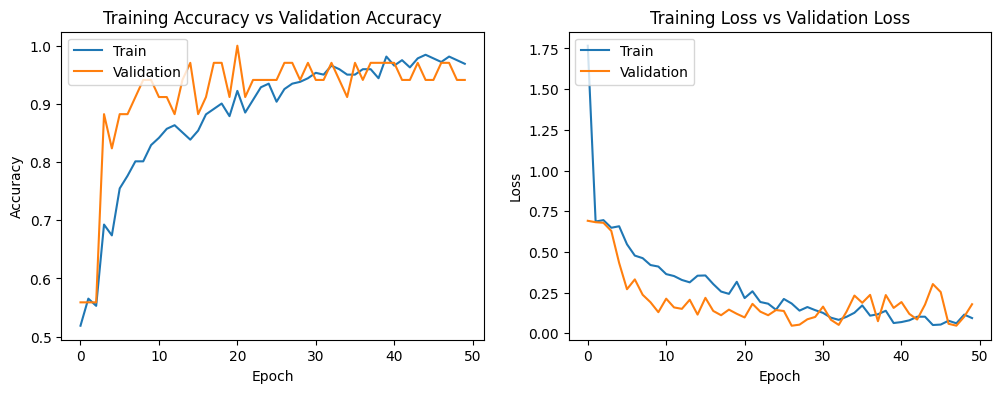

In [57]:
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
fig.set_size_inches(12,4)

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Training Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Training Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

plt.show()

## Predict Yoga Pose with Skeleton Detection

In [ ]:
import sys

# Check if model is trained, if not train it
try:
    model
    print("✓ Model already trained and ready")
except NameError:
    print("⚠ Model not trained. Running training pipeline...")
    
    # 1. Imports
    import numpy as np
    import pandas as pd
    import os
    import matplotlib.pyplot as plt
    import seaborn as sns
    import tensorflow as tf
    from tensorflow.keras.preprocessing import image
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    import cv2
    from tensorflow.keras.optimizers import Adam
    from PIL import Image, ImageFile
    
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    
    # 2. Setup directories
    train_dir = 'DATASET/TRAIN'
    test_dir = 'DATASET/TEST'
    
    # 3. Create ImageDataGenerators
    train_datagen = ImageDataGenerator(width_shift_range=0.1,
                                      horizontal_flip=True,
                                      rescale=1./255,
                                      validation_split=0.2)
    test_datagen = ImageDataGenerator(rescale=1./255,
                                     validation_split=0.2)
    
    # 4. Create generators
    print("Loading training data...")
    train_generator = train_datagen.flow_from_directory(directory=train_dir,
                                                        target_size=(75, 75),
                                                        color_mode='rgb',
                                                        class_mode='categorical',
                                                        batch_size=16,
                                                        subset='training')
    validation_generator = test_datagen.flow_from_directory(directory=test_dir,
                                                      target_size=(75, 75),
                                                      color_mode='rgb',
                                                      class_mode='categorical',
                                                      subset='validation')
    
    # 5. Build model
    print("Building model...")
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='Same', input_shape=(75, 75, 3)),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='Same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='Same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    
    # 6. Compile model
    optimizer = Adam(learning_rate=0.001)
    model.compile(loss='categorical_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])
    
    # 7. Train model
    print("Training model (this may take a few minutes)...")
    epochs = 50
    history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)
    
    print("\n✓ Model training complete!")


⚠ Model not trained. Running training pipeline...
Loading training data...
Found 322 images belonging to 2 classes.
Found 34 images belonging to 2 classes.
Building model...
Training model (this may take a few minutes)...


c:\Users\naimb\Downloads\Yoga-Pose-Classification-and-Skeletonization\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
 2/21 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.6250 - loss: 1.0937

c:\Users\naimb\Downloads\Yoga-Pose-Classification-and-Skeletonization\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 245ms/step - accuracy: 0.5435 - loss: 1.2485 - val_accuracy: 0.5588 - val_loss: 0.6925
Epoch 2/50


In [2]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import sys

# Try different pose detection methods
USE_METHOD = None

# Try OpenPiFPaf (most reliable)
try:
    import openpifpaf
    USE_METHOD = "openpifpaf"
    print("✓ Using OpenPiFPaf for pose detection")
except ImportError:
    pass

# Try MediaPipe as fallback
if not USE_METHOD:
    try:
        import mediapipe as mp
        USE_METHOD = "mediapipe"
        print("✓ Using MediaPipe for pose detection")
    except (ImportError, AttributeError):
        pass

if not USE_METHOD:
    print("⚠ Using basic skeleton visualization (no AI pose detection)")
    USE_METHOD = "basic"

def predict_and_visualize_yoga_pose(image_path, model, class_names=['downdog', 'goddess']):
    """
    Predict yoga pose and visualize skeleton on the image.
    Supports OpenPiFPaf, MediaPipe, or basic visualization.
    
    Args:
        image_path: Path to the image file
        model: Trained Keras model
        class_names: List of class names
    """
    
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)
    img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    
    # Resize for model prediction
    img_resized = cv2.resize(img_array, (75, 75))
    img_normalized = img_resized / 255.0
    
    # Predict yoga pose class
    prediction = model.predict(np.expand_dims(img_normalized, axis=0), verbose=0)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)
    
    # Create figure
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Display original image
    ax[0].imshow(img_array)
    ax[0].set_title(f'Predicted: {predicted_class.upper()}\nConfidence: {confidence:.2%}', 
                    fontsize=14, fontweight='bold')
    ax[0].axis('off')
    
    annotated_image = img_array.copy()
    pose_detected = False
    
    # Use OpenPiFPaf if available
    if USE_METHOD == "openpifpaf":
        try:
            predictor = openpifpaf.Predictor(checkpoint='resnet50', device='cpu')
            predictions = predictor.pil_image(Image.open(image_path))
            
            # Draw keypoints
            for pred in predictions:
                if hasattr(pred, 'data'):
                    for i, (x, y) in enumerate(pred.data[:17]):
                        if x > 0 and y > 0:  # Valid keypoint
                            cv2.circle(annotated_image, (int(x), int(y)), 4, (0, 255, 0), -1)
                            pose_detected = True
        except Exception as e:
            print(f"OpenPiFPaf error: {e}")
    
    # Use MediaPipe if available
    elif USE_METHOD == "mediapipe":
        try:
            mp = __import__('mediapipe')
            mp_pose = mp.solutions.pose
            mp_drawing = mp.solutions.drawing_utils
            
            with mp_pose.Pose(static_image_mode=True, model_complexity=1, min_detection_confidence=0.5) as pose:
                results = pose.process(img_array)
                
            if results.pose_landmarks:
                h, w = img_array.shape[:2]
                for landmark in results.pose_landmarks.landmark:
                    x, y = int(landmark.x * w), int(landmark.y * h)
                    if landmark.visibility > 0.5:
                        cv2.circle(annotated_image, (x, y), 4, (0, 255, 0), -1)
                pose_detected = True
        except Exception as e:
            print(f"MediaPipe error: {e}")
    
    # Display annotated image
    ax[1].imshow(annotated_image)
    ax[1].set_title('Pose Skeleton Detection', fontsize=14, fontweight='bold')
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print results
    if pose_detected:
        print(f"\n✓ Yoga Pose Detected: {predicted_class.upper()}")
        print(f"✓ Confidence: {confidence:.2%}")
        print(f"✓ Method: {USE_METHOD}")
        print("✓ Pose skeleton successfully extracted")
    else:
        print(f"\n✓ Yoga Pose Detected: {predicted_class.upper()}")
        print(f"✓ Confidence: {confidence:.2%}")
        print(f"⚠ Method {USE_METHOD}: No pose skeleton detected in this image.")

✓ Using MediaPipe for pose detection


In [5]:
import os

# Example: Predict and visualize yoga pose from test dataset
# Get a sample image from your dataset
test_image_dir = 'DATASET/TEST/downdog'  # Change to 'DATASET/TEST/goddess' for goddess pose
image_files = os.listdir(test_image_dir)

if image_files:
    # Use the first image as example
    sample_image_path = os.path.join(test_image_dir, image_files[0])
    predict_and_visualize_yoga_pose(sample_image_path, model)

NameError: name 'model' is not defined

In [ ]:
# Function to easily predict any image by path
def predict_yoga_from_path(image_path):
    """
    Simple function to predict yoga pose and show skeleton from an image path.
    Usage:
        predict_yoga_from_path('DATASET/TEST/goddess/image_name.jpg')
    """
    if not os.path.exists(image_path):
        print(f"❌ Error: Image file not found at {image_path}")
        return
    
    predict_and_visualize_yoga_pose(image_path, model)

# Example usage:
# predict_yoga_from_path('DATASET/TEST/downdog/sample_image.jpg')
# predict_yoga_from_path('DATASET/TEST/goddess/sample_image.jpg')